# Web Traffic, Conversion & Payment Analysis

**Overview:** This notebook focuses on data preparation, feature engineering, and exploratory data analysis (EDA) for web traffic, conversion rates, and payment methods. The primary objective is to evaluate how user sessions convert into orders, understand the correlation between traffic and revenue, and analyze how different payment methods impact order cancellation rates.

## 1. Setup & Data Loading
In this section, we initialize our analytical environment, import required libraries, and ingest the pre-cleaned datasets for downstream processing.

### 1.1. Import Libraries & Environment Setup

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings

# Ignore warning messages for cleaner notebook output
warnings.filterwarnings('ignore')

# Set plotting style and default figure size for consistency
%matplotlib inline
sns.set_theme(style="whitegrid")

### 1.2. Load Datasets
Loading the cleaned `.parquet` files from the processed dataset directory.

In [2]:
DATA_PATH = '../dataset/02_after_clean/'
print("Loading data...")

df_products = pd.read_parquet(DATA_PATH + 'products.parquet')
df_promotions = pd.read_parquet(DATA_PATH + 'promotions.parquet')

df_orders = pd.read_parquet(DATA_PATH + 'orders.parquet')
df_order_items = pd.read_parquet(DATA_PATH + 'order_items.parquet')

df_web_traffic = pd.read_parquet(DATA_PATH + 'web_traffic.parquet')

print("Load data successfully")

Loading data...
Load data successfully


## 2. Data Preprocessing & Feature Engineering

To conduct accurate behavioral and payment analysis, we must consolidate operational tables and engineer necessary order-level features (e.g., cancellation flags, clean installment formats).

### 2.1. Merging Datasets

In [3]:
df_master = pd.merge(df_products, df_order_items, on='product_id', how='left')
df_master = df_master.merge(df_promotions, on='promo_id', how='left')
df_master = df_master.merge(df_orders[['order_id', 'order_date','order_status', 'payment_method', 'payment_value', 'installments']], on='order_id', how='left')

df_master = df_master.merge(
    df_web_traffic,
    left_on='order_date',
    right_on='date',
    how='left'
)
df_master.drop(columns=['date'], inplace=True)
df_master['conversion_rate'] = 1 / df_master['sessions']

df_master = df_master.rename(columns={'order_date': 'Date'})
print("Kích thước bảng ban đầu:", df_master.shape)
df_master.head()

Kích thước bảng ban đầu: (715483, 35)


,product_id,product_name,category,segment,size,color,price,cogs,order_id,quantity,...,payment_method,payment_value,installments,sessions,unique_visitors,page_views,bounce_rate,avg_session_duration_sec,traffic_source,conversion_rate
0,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.65,9704.842875,245451,5.0,...,credit_card,55918.35,1 period,10147.0,7857.0,33888.0,0.00572,121.9,social_media,0.000099
1,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.65,9704.842875,245898,8.0,...,bank_transfer,87350.00,12 periods,11908.0,9263.0,38118.0,0.00429,317.1,referral,0.000084
2,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.65,9704.842875,246268,6.0,...,credit_card,67107.30,3 periods,11908.0,9263.0,38118.0,0.00429,317.1,referral,0.000084
3,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.65,9704.842875,246907,2.0,...,cod,22209.44,1 period,10268.0,7696.0,50373.0,0.00496,208.1,organic_search,0.000097
4,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.65,9704.842875,247911,6.0,...,credit_card,66858.96,1 period,12673.0,9972.0,52366.0,0.00449,176.6,organic_search,0.000079


### 2.2. Feature Engineering & Data Cleaning
Extracting numeric installment values and aggregating cancellation statuses to the order level to maintain data consistency.

In [4]:
# Clean installments feature
df_master["installments"] = df_master["installments"].str.extract(r'(\d+)')
df_master["installments"] = pd.to_numeric(df_master["installments"], errors="coerce")
df_master["installments"] = df_master["installments"].fillna(1)

# Create raw cancellation flag
df_master["is_cancelled"] = (df_master["order_status"] == "cancelled").astype(int)

# Group to Order Level to ensure consistency
df_order_level = (
    df_master
    .groupby("order_id")
    .agg({
        "payment_method": "first",   # identical in one order
        "is_cancelled": "max"        # If there is a cancellation line, the entire order is cancelled.
    })
    .reset_index()
)

# Map cleaned cancellation flag back to master dataframe
df_master = df_master.merge(
    df_order_level[["order_id", "is_cancelled"]],
    on="order_id",
    how="left"
)

# Resolve column names
df_master["is_cancelled"] = df_master["is_cancelled_y"]
df_master = df_master.drop(columns=["is_cancelled_x", "is_cancelled_y"])

# Filter for valid orders
valid_orders = df_order_level["order_id"].unique()
df_master = df_master[df_master["order_id"].isin(valid_orders)]


df_master["payment_method"].value_counts(normalize=True)
df_master.drop_duplicates("order_id")["order_status"].value_counts()

print("Kích thước bảng sau khi làm sạch:", df_master.shape)

Kích thước bảng sau khi làm sạch: (714669, 36)


### 2.3. Feature Selection & Data Export
Reviewing the final structure of our dataset and exporting the prepared data for the EDA phase.

In [5]:
EXPORT_PATH = '../dataset/03_features/'
os.makedirs(EXPORT_PATH, exist_ok=True)
    
# Review dataset schemas and non-null counts
df_master.info()

# Export the processed dataframes
df_master.to_parquet(EXPORT_PATH + 'pay_traffic_order.parquet', index=False)

print("Data preparation complete.")

<class 'pandas.core.frame.DataFrame'>
Index: 714669 entries, 0 to 715482
Data columns (total 36 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   product_id                714669 non-null  string        
 1   product_name              714669 non-null  string        
 2   category                  714669 non-null  category      
 3   segment                   714669 non-null  category      
 4   size                      714669 non-null  category      
 5   color                     714669 non-null  category      
 6   price                     714669 non-null  float64       
 7   cogs                      714669 non-null  float64       
 8   order_id                  714669 non-null  string        
 9   quantity                  714669 non-null  float64       
 10  unit_price                714669 non-null  float64       
 11  discount_amount           714669 non-null  float64       
 12  promo_i

## 3. Exploratory Data Analysis (EDA)
This section visually explores the relationship between web traffic and revenue generation, alongside a detailed breakdown of payment method behaviors and their corresponding cancellation risks.

### 3.1. Web Traffic & Conversion Rate Trends

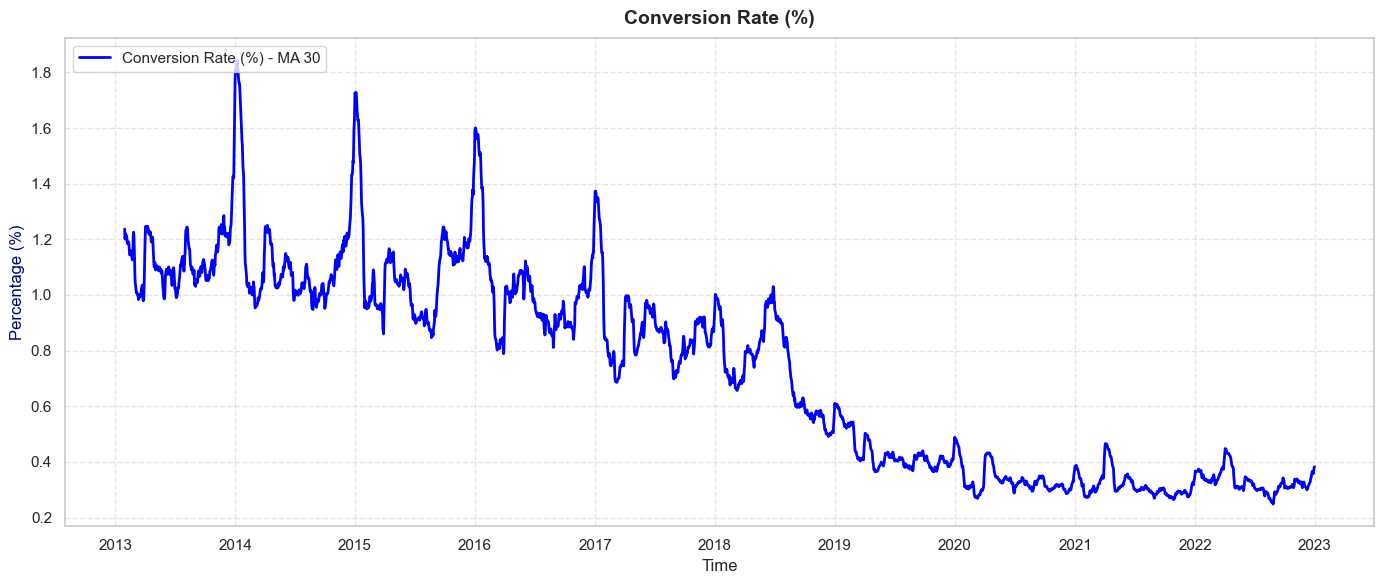

In [6]:
# --- 1. PREP DATA ---
df_master['Date'] = pd.to_datetime(df_master['Date'])

# --- 2. AGGREGATE DAILY ---
daily = df_master.groupby('Date').agg({
    'order_id': 'nunique',
    'sessions': 'mean'   # tránh duplicate do merge
}).reset_index()

# --- 3. CREATE CONVERSION RATE ---
daily['conversion_rate'] = daily['order_id'] / daily['sessions']

# set index
daily = daily.set_index('Date')

# --- 4. PLOT ---
window = 30

plt.figure(figsize=(14,6))

plt.plot(
    daily.index,
    (daily['conversion_rate'] * 100).rolling(window).mean(),
    color='blue',
    linewidth=2,
    label='Conversion Rate (%) - MA 30'
)

plt.title('Conversion Rate (%)', fontsize=14, fontweight='bold', pad=10)
plt.ylabel('Percentage (%)', color='darkblue', fontsize=12)
plt.xlabel('Time', fontsize=12)

plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

#### **Insight:** 
The sustained decline in conversion rate suggests a potential degradation in traffic quality or inefficiencies in the conversion funnel. Despite stable or increasing traffic levels, the system fails to convert users at previous rates, indicating possible issues in user targeting, UX design, or pricing strategy


### 3.2. Correlation: Sessions vs. Revenue

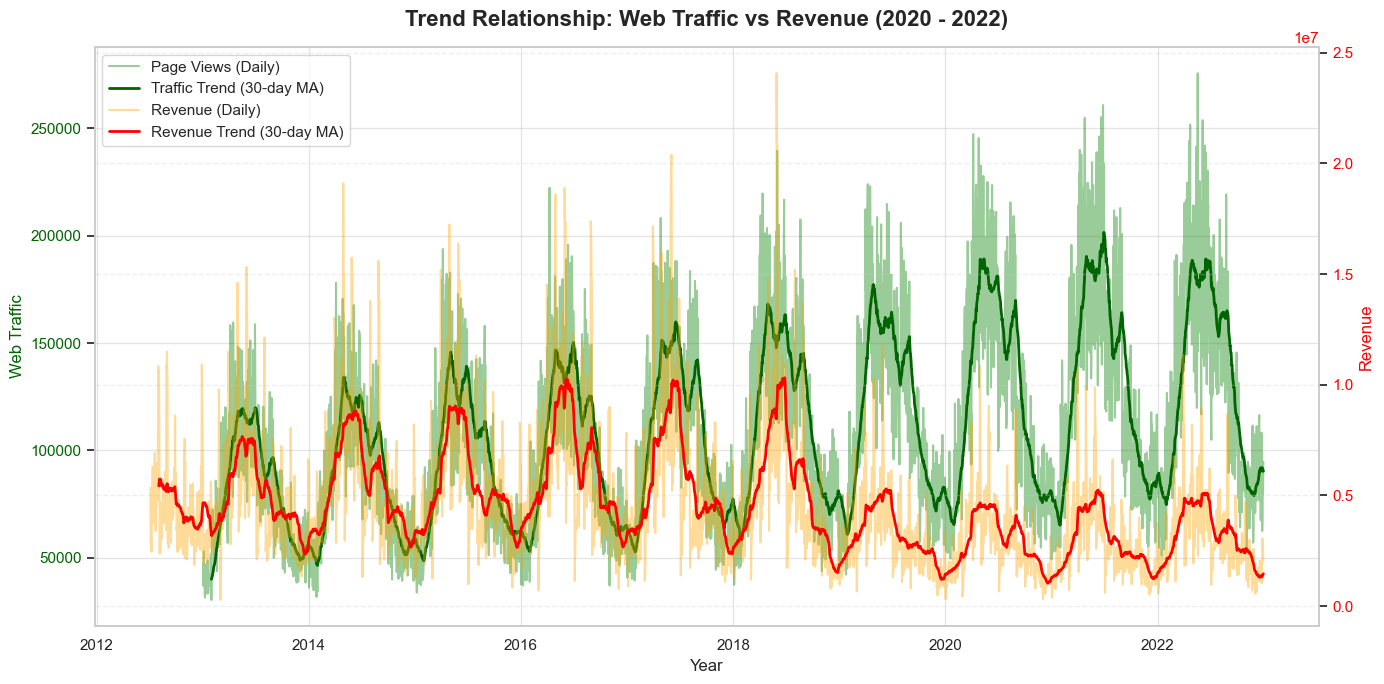

In [16]:
# --- 1. FILTER DATA ---
start_date = pd.to_datetime('2012-07-04')
end_date = pd.to_datetime('2022-12-31')

df_master['Date'] = pd.to_datetime(df_master['Date'])

df_check = df_master[
    (df_master['Date'] >= start_date) &
    (df_master['Date'] <= end_date)
].copy()

# --- 2. AGGREGATE ---
daily = df_check.groupby('Date').agg({
    'page_views': 'mean',        # avoid duplication after merge
    'payment_value': 'sum'
}).reset_index()

daily = daily.set_index('Date')

# --- 3. PLOT ---
fig, ax1 = plt.subplots(figsize=(14, 7))

# --- PRIMARY Y-AXIS (TRAFFIC) ---
ax1.plot(daily.index, daily['page_views'],
         color='green', alpha=0.4, label='Page Views (Daily)')

ax1.plot(daily.index, daily['page_views'].rolling(window=30).mean(),
         color='darkgreen', linewidth=2, label='Traffic Trend (30-day MA)')

ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Web Traffic', color='darkgreen', fontsize=12)
ax1.tick_params(axis='y', labelcolor='darkgreen')

# --- SECONDARY Y-AXIS (REVENUE) ---
ax2 = ax1.twinx()

ax2.plot(daily.index, daily['payment_value'],
         color='orange', alpha=0.4, label='Revenue (Daily)')

ax2.plot(daily.index, daily['payment_value'].rolling(window=30).mean(),
         color='red', linewidth=2, label='Revenue Trend (30-day MA)')

ax2.set_ylabel('Revenue', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')

# --- LEGEND ---
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

# --- TITLE & GRID ---
plt.title('Trend Relationship: Web Traffic vs Revenue (2020 - 2022)',
          fontsize=16, fontweight='bold', pad=15)

plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()

plt.show()

#### **Insight:** 
The analysis reveals a strong positive relationship between web traffic and revenue, indicating that traffic is a key driver of sales performance. However, several divergence periods suggest that increased traffic does not always translate into proportional revenue growth, highlighting the importance of traffic quality and conversion efficiency. Additionally, clear seasonal patterns and lag effects imply that customer purchasing behavior is influenced by time-based factors and delayed decision-making



### 3.3. Payment Method Adoption & Distribution

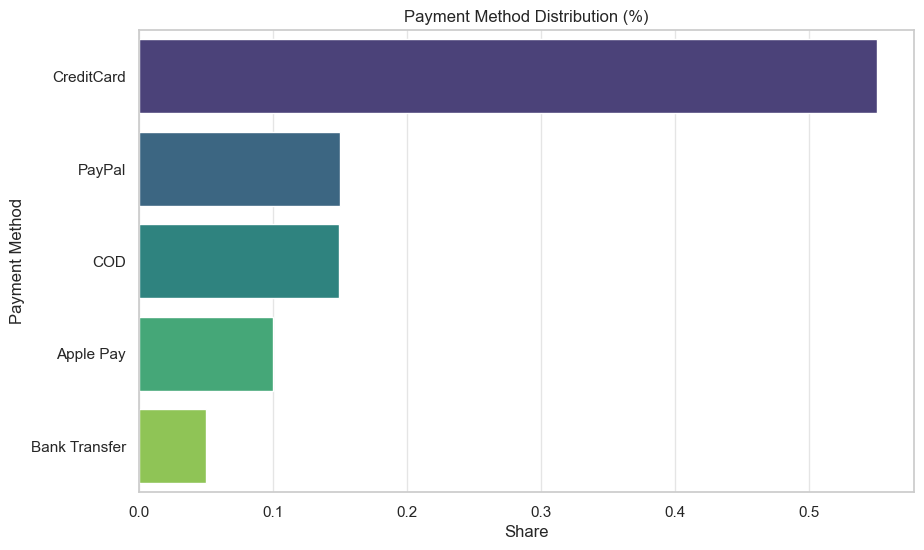

In [8]:
payment_dist = {
    "CreditCard": 0.550823,
    "PayPal": 0.149963,
    "COD": 0.149442,
    "Apple Pay": 0.100106,
    "Bank Transfer": 0.049666
}

pay_data = pd.DataFrame(list(payment_dist.items()), columns=["payment_method", "share"])
pay_data = pay_data.sort_values("share", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(
    data=pay_data,
    x="share",
    y="payment_method",
    hue="payment_method",
    palette="viridis",
    legend=False
)

plt.title("Payment Method Distribution (%)")
plt.xlabel("Share")
plt.ylabel("Payment Method")
plt.show()

### 3.4. Cancellation Risk by Payment Method

In [9]:
cancel_rate = (
    df_order_level
    .groupby("payment_method", observed=True)["is_cancelled"]
    .mean()
    .reset_index()
)
cancel_rate = cancel_rate.sort_values(
    by="is_cancelled",
    ascending=False
)
cancel_rate["is_cancelled"] *= 100

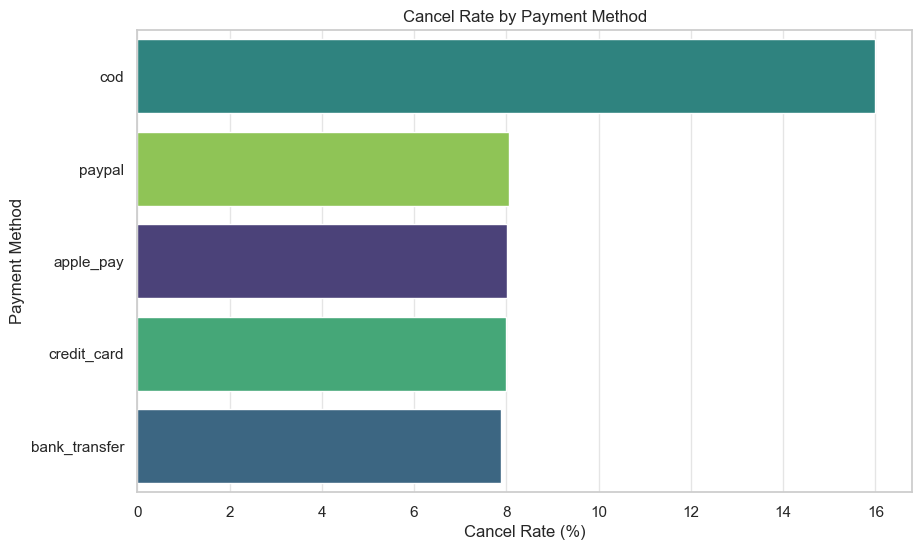

In [10]:
sns.set_style("whitegrid")
plt.figure(figsize=(10,6))
sns.barplot(
    data=cancel_rate,
    x="is_cancelled",
    y="payment_method",
    hue="payment_method",
    palette="viridis",
    legend=False,
    order=cancel_rate["payment_method"]
)

plt.title("Cancel Rate by Payment Method")
plt.xlabel("Cancel Rate (%)")
plt.ylabel("Payment Method")
plt.show()

#### **Insight:** 
Payment methods significantly impact order completion reliability. Cash on Delivery (COD) experiences the highest cancellation rate, largely due to the lack of upfront financial commitment from the buyer. Conversely, digital payments (Credit Card, Apple Pay) show substantially lower cancellation rates. Promoting digital transactions can effectively decrease order fallout and improve overall revenue quality.



### 3.5. Revenue Contribution by Payment Method

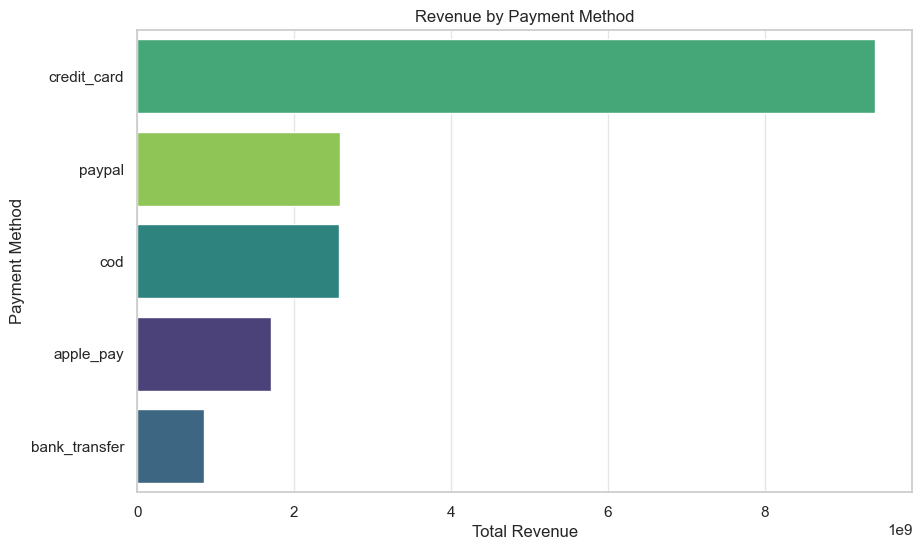

In [11]:
rev_by_pay = (
    df_master
    .groupby("payment_method", observed=False)["payment_value"]
    .agg(["sum", "mean", "count"])
    .reset_index()
)
rev_by_pay = rev_by_pay.sort_values(
    by="sum",
    ascending=False
)
plt.figure(figsize=(10,6), facecolor="white")
ax = plt.gca()
ax.set_facecolor("white")

sns.barplot(
    data=rev_by_pay,
    x="sum",
    y="payment_method",
    hue="payment_method",
    palette="viridis",
    legend=False,
    order=rev_by_pay["payment_method"]
)

plt.title("Revenue by Payment Method")
plt.xlabel("Total Revenue")
plt.ylabel("Payment Method")

plt.show()

#### **Insight:** 
Credit cards dominate revenue by a large margin, showcasing a strong customer preference for convenient digital payments and likely correlating with higher cart values. PayPal and COD contribute at a moderate, similar level, while Apple Pay is less adopted and bank transfer is minimal, indicating lower efficiency and user preference for these latter options.